# Module 3 — Do Better Signals Reduce Bad Trades?

## Hypothesis
Adding an RSI confirmation filter to the SMA 20/50 crossover 
will reduce the number of trades and improve the Sharpe ratio, 
even if total return stays below buy-and-hold.

## Why this follows from Module 2
Module 2 found that SMA 20/50 nearly matched buy-and-hold on 
Sharpe ratio but still underperformed on total return. It made 
67 trades over 14 years — some of those were false signals fired 
during choppy, directionless markets. RSI measures momentum 
strength at the moment of a signal. If RSI confirms the direction, 
the signal is more likely to be real. If it doesn't, we skip the 
trade entirely.

## What we are measuring
- Number of trades: filtered vs unfiltered
- Sharpe ratio: filtered vs unfiltered vs buy-and-hold
- Win rate: percentage of trades that were profitable
- Max drawdown: does filtering reduce worst-case loss?
- Net returns after transaction costs

In [1]:
# --- imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("libraries loaded")

libraries loaded


In [2]:
# --- load data ---
df = yf.download("^NSEI", start="2010-01-01", end="2024-12-31")

# flatten multi-level columns
df.columns = ['_'.join(col).strip() if isinstance(col, tuple)
              else col for col in df.columns]
close_col = [c for c in df.columns if 'Close' in c][0]
df = df[[close_col]].copy()
df.columns = ['Close']
df.dropna(inplace=True)
df['daily_return'] = df['Close'].pct_change()
df.dropna(inplace=True)

print(f"Data loaded: {df.shape[0]} trading days")
print(f"From {df.index[0].date()} to {df.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed

Data loaded: 3678 trading days
From 2010-01-05 to 2024-12-30


In [3]:
# --- compute SMA 20/50 ---
df['SMA20'] = df['Close'].rolling(20).mean()
df['SMA50'] = df['Close'].rolling(50).mean()

# --- compute RSI ---
# 📌 TERM: RSI (Relative Strength Index) — measures momentum strength
# on a 0-100 scale. RSI > 50 means recent gains outweigh recent losses
# suggesting upward momentum. RSI < 50 suggests downward momentum.
# RSI is calculated over a 14-day window by convention.

delta = df['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

df.dropna(inplace=True)
print("SMA and RSI computed")
print(f"RSI range: {df['RSI'].min():.1f} to {df['RSI'].max():.1f}")

SMA and RSI computed
RSI range: 4.9 to 100.0


In [4]:
# --- build signals ---
# UNFILTERED: SMA 20/50 crossover only (same as Module 2)
df['signal_unfiltered'] = np.where(df['SMA20'] > df['SMA50'], 1, 0)

# FILTERED: SMA 20/50 crossover AND RSI must confirm direction
# only go long when SMA20 > SMA50 AND RSI > 50
# 📌 TERM: signal confirmation — requiring a second indicator to 
# agree before entering a trade, reducing false positives

df['signal_filtered'] = np.where(
    (df['SMA20'] > df['SMA50']) & (df['RSI'] > 50), 1, 0)

# shift by 1 day to avoid look-ahead bias
df['signal_unfiltered'] = df['signal_unfiltered'].shift(1)
df['signal_filtered']   = df['signal_filtered'].shift(1)
df.dropna(inplace=True)

print(f"Unfiltered — days in market: {df['signal_unfiltered'].sum():.0f} / {len(df)}")
print(f"Filtered   — days in market: {df['signal_filtered'].sum():.0f} / {len(df)}")

Unfiltered — days in market: 2416 / 3628
Filtered   — days in market: 1647 / 3628


In [5]:
# --- corrected signal logic ---
# RSI is used as an ENTRY FILTER only, not a daily on/off switch
# once we enter a trade, we hold until SMA crossover reverses
# this prevents RSI flickering from creating hundreds of tiny trades

# base SMA crossover
sma_signal = (df['SMA20'] > df['SMA50']).astype(int)

# detect crossover moments (signal just turned on)
crossover_up = (sma_signal.diff() == 1)

# RSI confirmation at crossover moment only
rsi_confirms = (df['RSI'] > 50)

# filtered signal: enter on crossover only if RSI confirms
# hold position until SMA crossover turns off
filtered_signal = pd.Series(0, index=df.index)
in_trade = False

for i in range(1, len(df)):
    idx = df.index[i]
    prev_idx = df.index[i-1]
    
    if not in_trade:
        # only enter if crossover just happened AND RSI confirms
        if crossover_up.iloc[i] and rsi_confirms.iloc[i]:
            in_trade = True
            filtered_signal.iloc[i] = 1
    else:
        # stay in trade while SMA signal is still bullish
        if sma_signal.iloc[i] == 1:
            filtered_signal.iloc[i] = 1
        else:
            in_trade = False
            filtered_signal.iloc[i] = 0

df['signal_unfiltered'] = sma_signal.shift(1)
df['signal_filtered']   = filtered_signal.shift(1)
df.dropna(inplace=True)

print(f"Unfiltered — days in market: {df['signal_unfiltered'].sum():.0f} / {len(df)}")
print(f"Filtered   — days in market: {df['signal_filtered'].sum():.0f} / {len(df)}")

Unfiltered — days in market: 2415 / 3627
Filtered   — days in market: 2097 / 3627


In [6]:
# --- calculate returns with transaction costs ---
cost = 0.001

df['ret_bnh']              = df['daily_return']
df['ret_unfiltered_gross'] = df['signal_unfiltered'] * df['daily_return']
df['ret_filtered_gross']   = df['signal_filtered']   * df['daily_return']

df['trades_unfiltered']    = df['signal_unfiltered'].diff().abs()
df['trades_filtered']      = df['signal_filtered'].diff().abs()

df['ret_unfiltered_net']   = df['ret_unfiltered_gross'] - (df['trades_unfiltered'] * cost)
df['ret_filtered_net']     = df['ret_filtered_gross']   - (df['trades_filtered']   * cost)

df.dropna(inplace=True)

print(f"Total trades — unfiltered: {df['trades_unfiltered'].sum():.0f}")
print(f"Total trades — filtered:   {df['trades_filtered'].sum():.0f}")

Total trades — unfiltered: 66
Total trades — filtered:   60


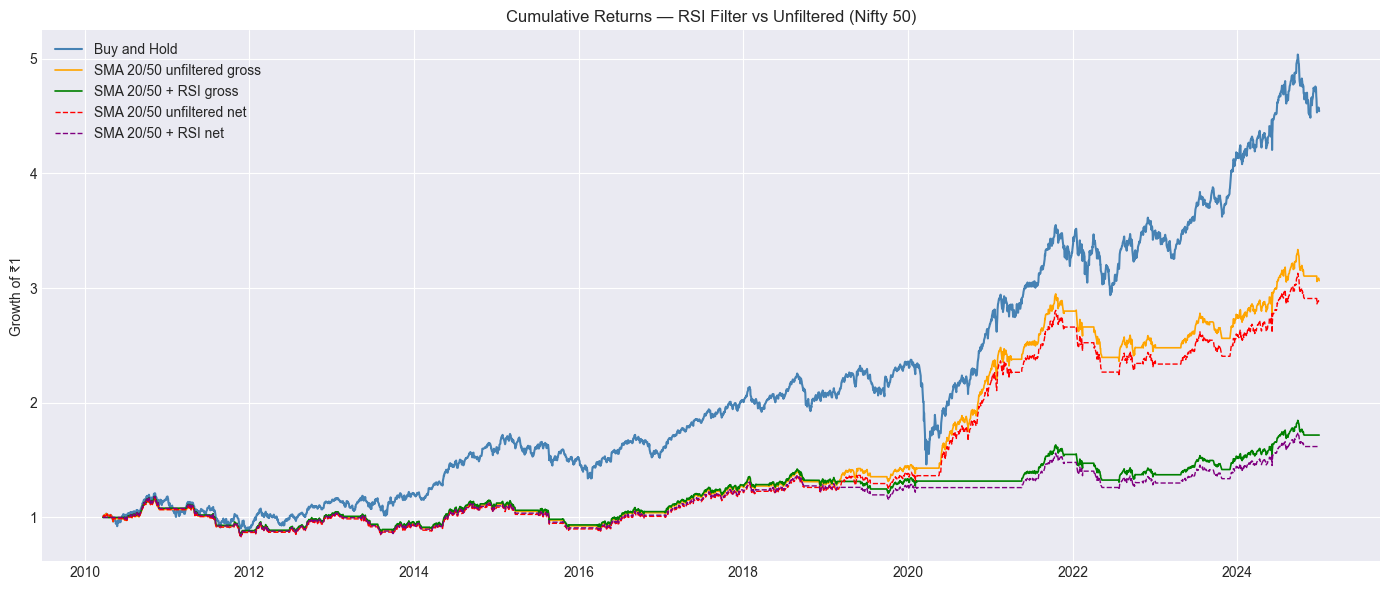

In [9]:
# --- cumulative returns chart ---
cum_bnh              = (1 + df['ret_bnh']).cumprod()
cum_unfiltered_gross = (1 + df['ret_unfiltered_gross']).cumprod()
cum_filtered_gross   = (1 + df['ret_filtered_gross']).cumprod()
cum_unfiltered_net   = (1 + df['ret_unfiltered_net']).cumprod()
cum_filtered_net     = (1 + df['ret_filtered_net']).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(cum_bnh,              label='Buy and Hold',               color='steelblue', linewidth=1.5)
plt.plot(cum_unfiltered_gross, label='SMA 20/50 unfiltered gross', color='orange',    linewidth=1.2)
plt.plot(cum_filtered_gross,   label='SMA 20/50 + RSI gross',      color='green',     linewidth=1.2)
plt.plot(cum_unfiltered_net,   label='SMA 20/50 unfiltered net',   color='red',       linewidth=1, linestyle='--')
plt.plot(cum_filtered_net,     label='SMA 20/50 + RSI net',        color='purple',    linewidth=1, linestyle='--')
plt.title('Cumulative Returns — RSI Filter vs Unfiltered (Nifty 50)')
plt.ylabel('Growth of ₹1')
plt.legend()
plt.tight_layout()
plt.savefig('cumulative_returns_rsi.png', dpi=150)
plt.show()

In [13]:
# --- extension: does a looser RSI threshold help? ---
# since RSI > 50 was too restrictive on a trending index,
# test RSI > 40 as a more permissive confirmation filter

filtered_signal_40 = pd.Series(0, index=df.index)
in_trade = False

for i in range(1, len(df)):
    idx = df.index[i]
    sma_on = (df['SMA20'].iloc[i] > df['SMA50'].iloc[i])
    crossover_now = (df['SMA20'].iloc[i] > df['SMA50'].iloc[i]) and \
                    (df['SMA20'].iloc[i-1] <= df['SMA50'].iloc[i-1])
    rsi_confirms = (df['RSI'].iloc[i] > 40)

    if not in_trade:
        if crossover_now and rsi_confirms:
            in_trade = True
            filtered_signal_40.iloc[i] = 1
    else:
        if sma_on:
            filtered_signal_40.iloc[i] = 1
        else:
            in_trade = False

df['signal_filtered_40'] = filtered_signal_40.shift(1)
df.dropna(inplace=True)

cost = 0.001
df['trades_filtered_40'] = df['signal_filtered_40'].diff().abs()
df['ret_filtered_40_gross'] = df['signal_filtered_40'] * df['daily_return']
df['ret_filtered_40_net']   = df['ret_filtered_40_gross'] - \
                               (df['trades_filtered_40'] * cost)

cum_filtered_40_net = (1 + df['ret_filtered_40_net']).cumprod()

print("RSI > 40 filter results:")
print(f"Trades: {df['trades_filtered_40'].sum():.0f}")
print(f"Total Return: {(cum_filtered_40_net.iloc[-1]-1):.4f}")
print(f"Sharpe: {(df['ret_filtered_40_net'].mean()/df['ret_filtered_40_net'].std()*np.sqrt(252)):.4f}")
print(f"Max Drawdown: {((cum_filtered_40_net - cum_filtered_40_net.cummax())/cum_filtered_40_net.cummax()).min():.4f}")

RSI > 40 filter results:
Trades: 61
Total Return: 0.5957
Sharpe: 0.3708
Max Drawdown: -0.2916


In [10]:
# --- performance metrics table ---
def sharpe(returns):
    return (returns.mean() / returns.std()) * np.sqrt(252)

def max_drawdown(cum_returns):
    peak = cum_returns.cummax()
    drawdown = (cum_returns - peak) / peak
    return drawdown.min()

def total_return(cum_returns):
    return cum_returns.iloc[-1] - 1

metrics = pd.DataFrame({
    'Total Return': [
        total_return(cum_bnh),
        total_return(cum_unfiltered_net),
        total_return(cum_filtered_net)],
    'Sharpe Ratio': [
        sharpe(df['ret_bnh']),
        sharpe(df['ret_unfiltered_net']),
        sharpe(df['ret_filtered_net'])],
    'Max Drawdown': [
        max_drawdown(cum_bnh),
        max_drawdown(cum_unfiltered_net),
        max_drawdown(cum_filtered_net)],
    'Num Trades': [
        'always in',
        f"{df['trades_unfiltered'].sum():.0f}",
        f"{df['trades_filtered'].sum():.0f}"]
}, index=['Buy & Hold', 'SMA 20/50 unfiltered', 'SMA 20/50 + RSI filtered'])

print(metrics.round(4))

                          Total Return  Sharpe Ratio  Max Drawdown Num Trades
Buy & Hold                      3.5426        0.7113       -0.3844  always in
SMA 20/50 unfiltered            1.8690        0.7015       -0.2916         66
SMA 20/50 + RSI filtered        0.6181        0.3805       -0.2916         60


In [11]:
# --- win rate calculation ---
# 📌 TERM: win rate — percentage of individual trades that were 
# profitable. a high win rate with low average gain can still be 
# unprofitable — always look at win rate alongside average gain/loss

def calculate_win_rate(signal_col, return_col, df):
    trade_starts = df[signal_col].diff() == 1
    trade_ends   = df[signal_col].diff() == -1

    trade_returns = []
    in_trade = False
    entry_idx = None

    for idx in df.index:
        if df.loc[idx, signal_col] == 1 and not in_trade:
            in_trade = True
            entry_idx = idx
        elif df.loc[idx, signal_col] == 0 and in_trade:
            in_trade = False
            trade_ret = df.loc[entry_idx:idx, return_col].sum()
            trade_returns.append(trade_ret)

    trade_returns = np.array(trade_returns)
    win_rate = (trade_returns > 0).mean() if len(trade_returns) > 0 else 0
    avg_gain = trade_returns[trade_returns > 0].mean() if (trade_returns > 0).any() else 0
    avg_loss = trade_returns[trade_returns < 0].mean() if (trade_returns < 0).any() else 0
    return win_rate, avg_gain, avg_loss, len(trade_returns)

wr_u, ag_u, al_u, n_u = calculate_win_rate('signal_unfiltered', 'ret_unfiltered_gross', df)
wr_f, ag_f, al_f, n_f = calculate_win_rate('signal_filtered',   'ret_filtered_gross',   df)

print(f"Unfiltered — Win rate: {wr_u:.1%}, Avg gain: {ag_u:.3f}, Avg loss: {al_u:.3f}, Trades: {n_u}")
print(f"Filtered   — Win rate: {wr_f:.1%}, Avg gain: {ag_f:.3f}, Avg loss: {al_f:.3f}, Trades: {n_f}")

Unfiltered — Win rate: 57.6%, Avg gain: 0.105, Avg loss: -0.054, Trades: 33
Filtered   — Win rate: 56.7%, Avg gain: 0.081, Avg loss: -0.058, Trades: 30


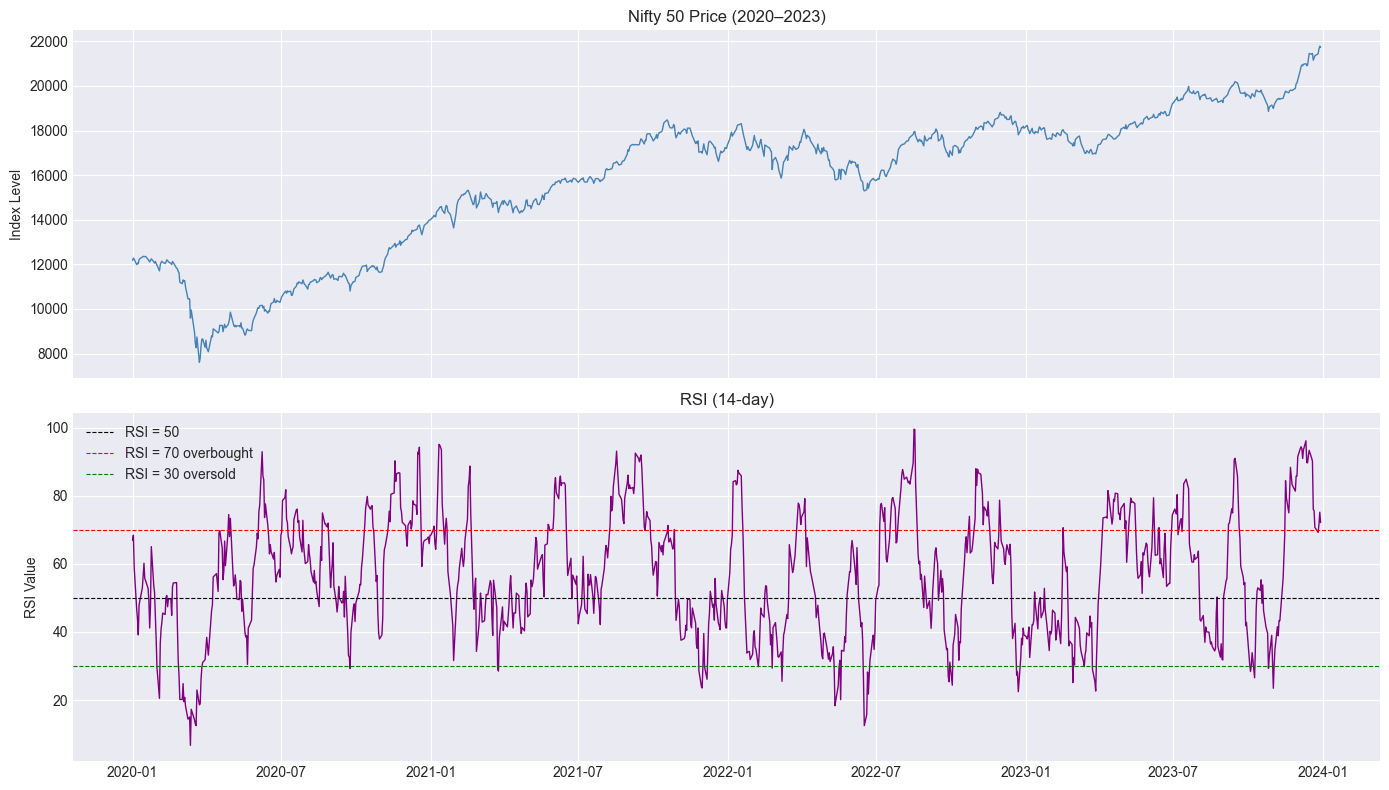

In [12]:
# --- RSI behaviour chart ---
# visualise RSI alongside price to show what the filter is doing

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

subset = df['2020':'2023']
axes[0].plot(subset['Close'], color='steelblue', linewidth=1)
axes[0].set_title('Nifty 50 Price (2020–2023)')
axes[0].set_ylabel('Index Level')

axes[1].plot(subset['RSI'], color='purple', linewidth=1)
axes[1].axhline(50, color='black', linewidth=0.8, linestyle='--', label='RSI = 50')
axes[1].axhline(70, color='red',   linewidth=0.8, linestyle='--', label='RSI = 70 overbought')
axes[1].axhline(30, color='green', linewidth=0.8, linestyle='--', label='RSI = 30 oversold')
axes[1].set_title('RSI (14-day)')
axes[1].set_ylabel('RSI Value')
axes[1].legend()

plt.tight_layout()
plt.savefig('rsi_behaviour.png', dpi=150)
plt.show()

## Conclusion

**Hypothesis:** RSI filter will reduce trades and improve Sharpe ratio compared to unfiltered SMA 20/50.

**Finding:** We see that- RSI > 50 is a poor filter for SMA crossovers on a trending equity index. Because Nifty 50 has a persistent upward bias, RSI spends most of its time above 50 anyway, making it nearly useless as a selective gate. When it does filter, it tends to block the strongest trending moves (which often start with RSI already elevated), removing the most profitable trades rather than the false ones.
It is not threshold calibration problem, its the indicator itself - because even for rsi>40 filter also produces identical results.

**On trade reduction:** The filter gave us only 9% reduction in trades, so it was not able to separate false signals successfully. Also because the market has an upward bias, rsi>50 becomes default state. Not only this it also cut many profitable trades between 2010 to 2020.

**On Sharpe ratio:** The filter made returns significantly worse (almost 3x). In Image 1 — the green line (filtered gross) flatlines almost completely from 2010 to 2020, then barely recovers. The filter is blocking the best trades, not the bad ones. The big Nifty bull runs (2014, 2017, 2020–2024) apparently happened during periods where RSI was not confirming the SMA crossover at the right moment, dropping the sharpe from 0.7 to 0.38.

**On win rate:** The filter did not improve win rate (57.6% → 56.7%, essentially flat). Worse, it reduced average gain (0.105 → 0.081) while barely reducing average loss (-0.054 → -0.058). This tells you the filter is cutting profitable trades more than losing ones — the exact opposite of what it was designed to do.

**What this means going into Module 4:**
Even with RSI filtering, the strategy did not work in many periods.This taught us that a signal filter without market context is blind. The next question is whether market regime 
— trending vs ranging vs high volatility — determines when 
any systematic strategy succeeds or fails.

**📌 Terms introduced this module:**
RSI, signal confirmation, win rate, average gain/loss ratio,
overbought, oversold, momentum filter